# ECG Signal Processing

## 1. Load ECG Data

This section loads a public ECG recording from the MIT-BIH Arrhythmia Database using the WFDB library.

In [1]:
import wfdb
import matplotlib.pyplot as plt

In [2]:
record = wfdb.rdrecord(
    '100',
    pn_dir='mitdb',
    sampto=3000
)

signal = record.p_signal[:, 0]
fs = record.fs

print("Sampling frequency:", fs)
print("Number of samples:", len(signal))

Sampling frequency: 360
Number of samples: 3000


## 2. Visualize the ECG Signal

The ECG signal is plotted in the time domain to inspect its morphology.

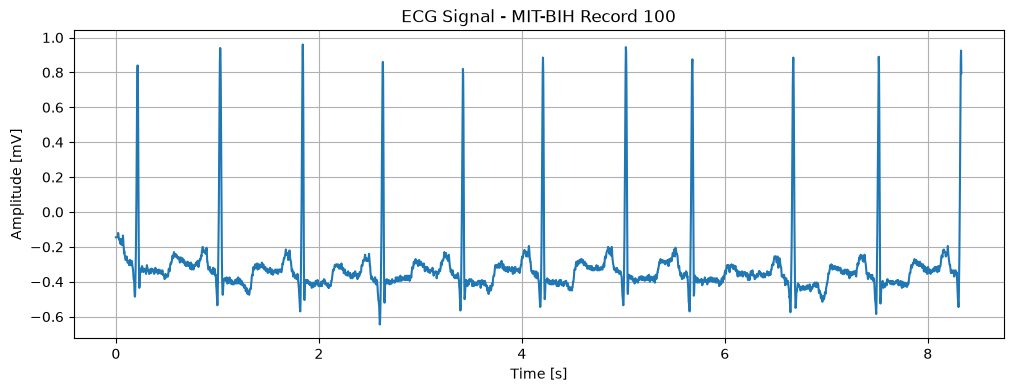

In [3]:
time = [i / fs for i in range(len(signal))]

plt.figure(figsize=(12, 4))
plt.plot(time, signal)
plt.xlabel("Time [s]")
plt.ylabel("Amplitude [mV]")
plt.title("ECG Signal - MIT-BIH Record 100")
plt.grid()
plt.show()

## 3. Detect R-Peaks

R-peaks are detected using a simple amplitude threshold and minimum-distance criterion.

In [5]:
import numpy as np

threshold = 0.5
min_distance = 200

candidate_peaks = np.where(signal > threshold)[0]

peaks = []

for p in candidate_peaks:
    if len(peaks) == 0 or p - peaks[-1] > min_distance:
        window_end = min(p + 20, len(signal))
        local_peak = p + np.argmax(signal[p:window_end])
        peaks.append(local_peak)

peaks = np.array(peaks)

print("Detected R-peaks:", len(peaks))

Detected R-peaks: 11


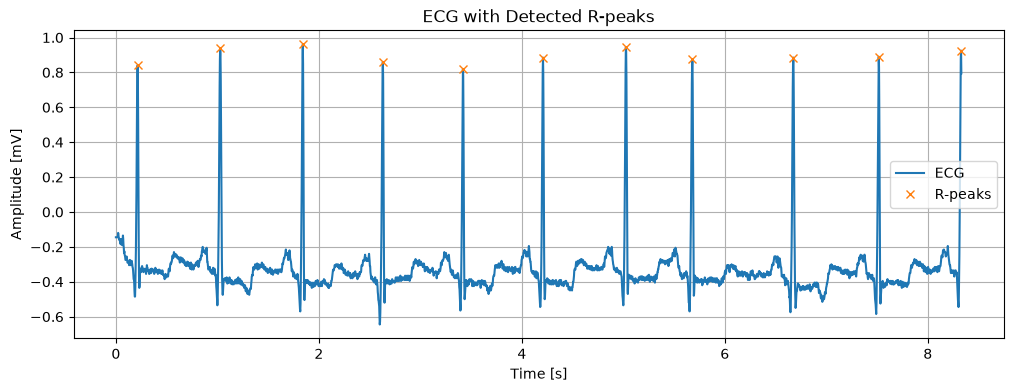

In [6]:
plt.figure(figsize=(12, 4))
plt.plot(time, signal, label="ECG")

plt.plot(
    [time[p] for p in peaks],
    [signal[p] for p in peaks],
    "x",
    label="R-peaks"
)

plt.xlabel("Time [s]")
plt.ylabel("Amplitude [mV]")
plt.title("ECG with Detected R-peaks")
plt.legend()
plt.grid()
plt.show()

## 4. Estimate Heart Rate

RR intervals are calculated from consecutive R-peaks and converted to heart rate in beats per minute (BPM).

In [7]:
rr_intervals = np.diff(peaks) / fs

heart_rate = 60 / rr_intervals

print("RR intervals [s]:")
print(rr_intervals)

print("\nHeart rate [BPM]:")
print(heart_rate)

print("\nAverage heart rate:")
print(round(np.mean(heart_rate), 1), "BPM")

RR intervals [s]:
[0.81388889 0.81388889 0.78888889 0.78888889 0.78888889 0.81666667
 0.65555556 0.99444444 0.84166667 0.81111111]

Heart rate [BPM]:
[73.72013652 73.72013652 76.05633803 76.05633803 76.05633803 73.46938776
 91.52542373 60.33519553 71.28712871 73.97260274]

Average heart rate:
74.6 BPM


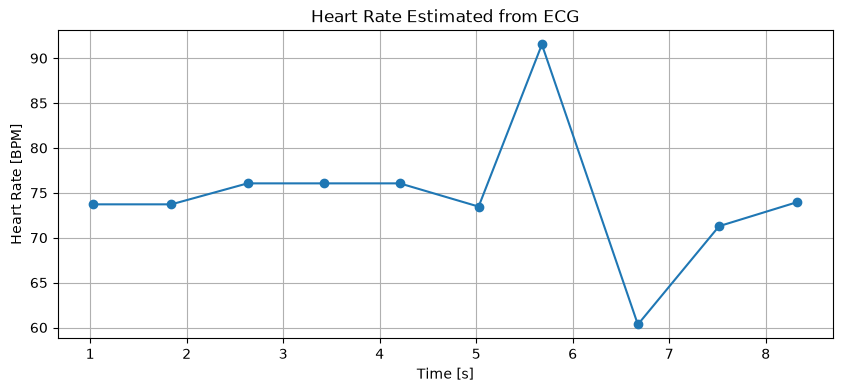

In [8]:
rr_times = [time[p] for p in peaks[1:]]

plt.figure(figsize=(10, 4))
plt.plot(rr_times, heart_rate, marker="o")

plt.xlabel("Time [s]")
plt.ylabel("Heart Rate [BPM]")
plt.title("Heart Rate Estimated from ECG")
plt.grid()
plt.show()

## Results

The analysis detected 11 R-peaks in approximately 8 seconds of ECG data.

The estimated average heart rate was approximately **74.6 BPM**.

Most beat-to-beat heart-rate estimates were between 70 and 80 BPM, with some variation between consecutive RR intervals.

## Limitations

The current R-peak detection method uses a simple amplitude threshold and is intended as a first implementation.

Future improvements may include:

- ECG filtering
- more robust R-peak detection
- analysis of longer recordings
- heart-rate variability analysis
- comparison with annotated reference beats